In [12]:
from pathlib import Path
import importlib
import sys
import matplotlib.pyplot as plt

project_root = next((parent for parent in [Path.cwd(), *Path.cwd().parents] if (parent / 'src').exists()), Path.cwd())
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data_loader import TimeSeriesDataLoader
from src.models import statistical as statistical_module
importlib.reload(statistical_module)
StatisticalForecaster = statistical_module.StatisticalForecaster

## MSTL Decomposition

In [13]:
print("Loading Data...")
loader = TimeSeriesDataLoader()
df = loader.load_and_clean(project_root / 'data' / 'raw' / 'Internal Submission Hourly 2024.csv')

target_col = 'Carbon intensity gCO₂eq/kWh (direct)'
train_data = df[target_col]

print("\nRunning MSTL...")
stats_model = StatisticalForecaster()
res, trend, seasonal_24, seasonal_168, residual = stats_model.run_mstl_decomposition(train_data)


Loading Data...
Loading data from /Users/justdann/Documents/Telkom_University/Outside_Classes/Research/CarbonIntensityResearch/app/data/raw/Internal Submission Hourly 2024.csv...
Data cleaned. Total baris: 8784

Running MSTL...
Running MSTL Decomposition...



Visualizing MSTL Decomposition...


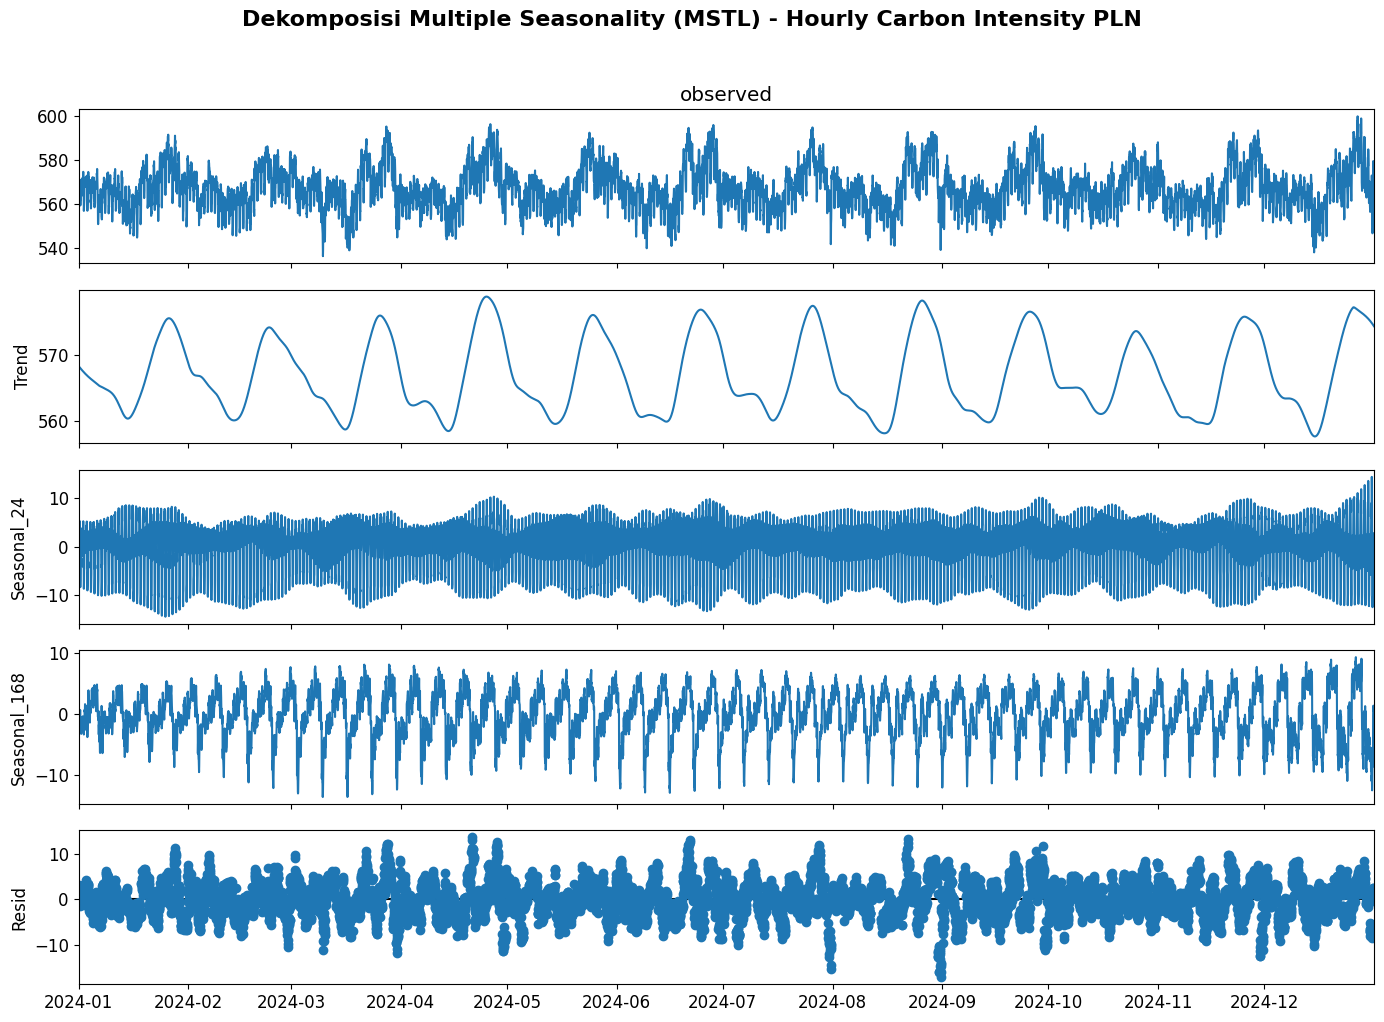

In [8]:
print("\nVisualizing MSTL Decomposition...")
plt.rc('figure', figsize=(14, 10))
plt.rc('font', size=12)

fig = res.plot()
fig.suptitle('Dekomposisi Multiple Seasonality (MSTL) - Hourly Carbon Intensity PLN', 
             fontsize=16, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

#### Observed:
Data Hourly Carbon Intensity PLN sepanjang 2024 berfluktuasi di kisaran 540–600 gCO₂eq/kWh, dengan volatilitas yang cukup tinggi — konsisten dengan intermittensi EBT yang jadi latar belakang penelitianmu.
#### Trend:
Komponen trend menunjukkan pola osilasi bulanan (bukan tren linear), bergerak antara ~560–580. Ini menarik — bukan tren naik/turun stabil, melainkan siklus jangka menengah yang kemungkinan mencerminkan perubahan seasonal dalam bauran energi PLN (misalnya, musim hujan → lebih banyak hidro → CI lebih rendah). Secara keseluruhan relatif stasioner dalam jangka panjang.
#### Seasonal_24 (Daily):
Amplitudo ±10–15 gCO₂eq/kWh. Pola harian sangat konsisten dan stabil sepanjang tahun. Ini adalah seasonality paling dominan secara reguler — mencerminkan variasi permintaan listrik dan kontribusi surya dalam satu hari.
#### Seasonal_168 (Weekly):
Amplitudo ±8–10 gCO₂eq/kWh, dengan struktur yang lebih kompleks dan sedikit lebih bervariasi dibanding seasonal_24. Mencerminkan perbedaan pola konsumsi antara hari kerja vs. akhir pekan.
#### Residual:
Tersebar ±10–15, dengan beberapa outlier ekstrem di sekitar Agustus–September 2024 (mendekati -15). Perlu diperiksa apakah ini event khusus (misalnya blackout, peningkatan tiba-tiba EBT). Residu yang relatif kecil dibanding sinyal mengindikasikan MSTL berhasil menangkap sebagian besar struktur.


## PROPHET DECOMPOSITION

22:35:23 - cmdstanpy - INFO - Chain [1] start processing


Running Prophet Decomposition...


22:35:24 - cmdstanpy - INFO - Chain [1] done processing


Membangun grafik dekomposisi Prophet...


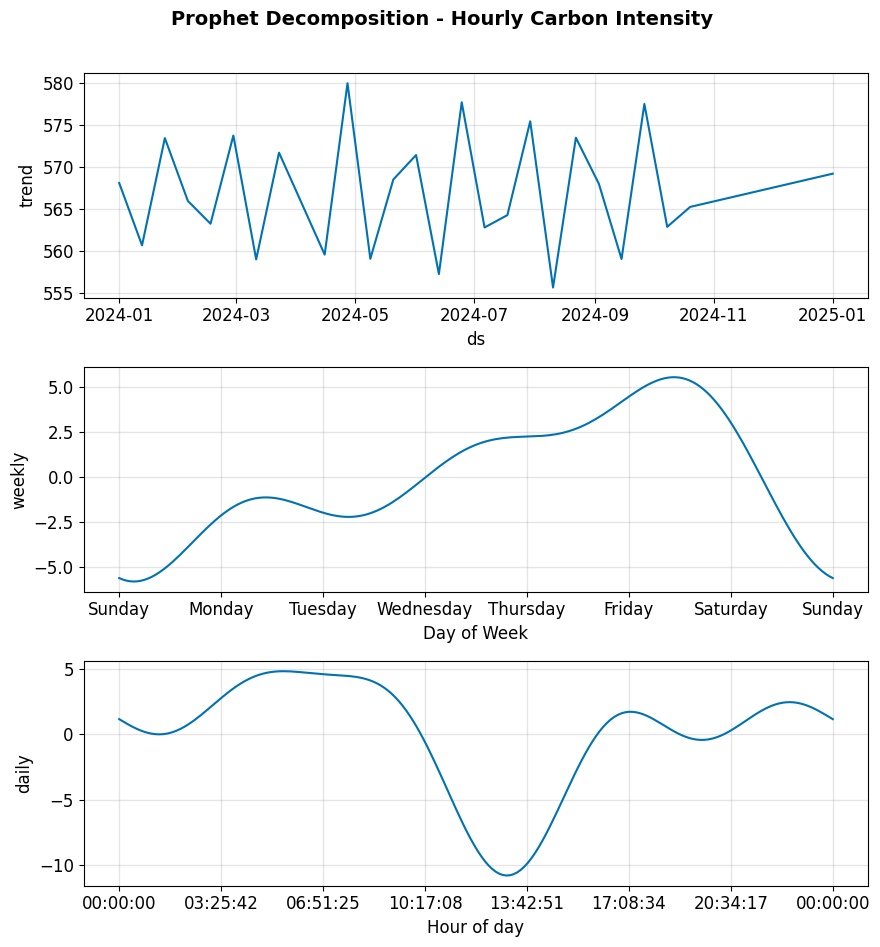

In [19]:

prophet_df = df.reset_index()[['Datetime (UTC)', target_col]].copy()
prophet_df.columns = ['ds', 'y']

# Run Model
prophet_model, prophet_decomp = stats_model.run_prophet_decomposition(prophet_df)

# Visualisasi
print("Membangun grafik dekomposisi Prophet...")
fig_prophet = prophet_model.plot_components(prophet_decomp, uncertainty=False)
fig_prophet.suptitle('Prophet Decomposition - Hourly Carbon Intensity', fontsize=14, y=1.05, fontweight='bold')
plt.show()

#### Trend:
Prophet menangkap trend sebagai garis yang sangat "spiky" (naik-turun tajam), bukan smooth seperti MSTL. Ini gejala overfitting trend pada changepoints - Prophet terlalu agresif mendeteksi perubahan tren, padahal itu mungkin bagian dari seasonality jangka menengah. Ini justru menunjukkan mengapa MSTL lebih superior dalam mengisolasi trend untuk data ini.


#### Weekly Seasonality:
- Minggu paling rendah (~-5.5): Aktivitas industri rendah → permintaan turun → proporsi RE lebih tinggi → CI turun
- Jumat–Sabtu tertinggi (~+5.5): Puncak aktivitas ekonomi → beban baseload fosil naik
- Ini konsisten dengan hipotesis penelitian tentang pengaruh pola konsumsi terhadap CI

#### Daily Seasonality:

- Puncak pagi ~06:00–07:00 (+5): Demand morning ramp-up
- lembah siang ~13:00 (-10): Sangat dalam. "kemungkinan" kontribusi solar PV pada jam siang menekan CI
- Recovery sore 17:00+: Solar turun, pembangkit fosil kembali mendominasi
- Pola ini adalah bukti kuat pengaruh solar intermittency terhadap CI harian

## AR, MA, & SARIMAX + FOURIER

In [ ]:
# Ambil subset 1 bulan pertama (720 baris) untuk testing cepet
train_subset = train_data.iloc[:720]

# AutoRegressive (AR)
print("Training AR(24)... (Melihat 24 jam ke belakang)")
ar_results = stats_model.run_ar_model(train_subset, p=24)
print(f"AR Selesai! AIC Score: {ar_results.aic:.2f}")

# Moving Average (MA)
print("\nTraining MA(24)... (Melihat error 24 jam ke belakang)")
ma_results = stats_model.run_ma_model(train_subset, q=24)
print(f"MA Selesai! AIC Score: {ma_results.aic:.2f}")

# SARIMAX + Fourier
print("\nTraining SARIMAX + Fourier (Daily & Weekly Seasonality)...")
sarimax_results = stats_model.run_sarimax_fourier(train_subset)
print(f"SARIMAX Selesai! AIC Score: {sarimax_results.aic:.2f}")

print(sarimax_results.summary())

Training AR(24)... (Melihat 24 jam ke belakang)
Running AR(24) model...
AR Selesai! AIC Score: 3593.90

Training MA(24)... (Melihat error 24 jam ke belakang)
Running MA(24) model...


/Users/justdann/Documents/Telkom_University/Outside_Classes/Research/CarbonIntensityResearch/app/.venv/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/justdann/Documents/Telkom_University/Outside_Classes/Research/CarbonIntensityResearch/app/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


MA Selesai! AIC Score: 3583.45

Training SARIMAX + Fourier (Daily & Weekly Seasonality)...
Running SARIMAX with Fourier features...
SARIMAX Selesai! AIC Score: 3752.47
                                        SARIMAX Results                                         
Dep. Variable:     Carbon intensity gCO₂eq/kWh (direct)   No. Observations:                  720
Model:                                 SARIMAX(1, 1, 1)   Log Likelihood               -1865.234
Date:                                  Thu, 30 Apr 2026   AIC                           3752.467
Time:                                          21:57:49   BIC                           3802.824
Sample:                                      01-01-2024   HQIC                          3771.909
                                           - 01-30-2024                                         
Covariance Type:                                    opg                                         
                 coef    std err          z      P>|z|  

AIC, 3752.47, Lebih tinggi dari MA (3583.45) — model lebih kompleks tapi fit lebih buruk relatif

AR(1) coef, 0.583(p<0.001), Autokorelasi lag-1 kuat, CI jam ini dipengaruhi jam lalu

MA(1) coef, -0.911(p<0.001), Koreksi error sangat kuat

sin/cos(1,24) & (2,24), Signifikan (p<0.001), Fourier terms harian berhasil ditangkap

sin/cos(1,168), cos signifikan (p=0.012) sin tidak, Seasonality mingguan sebagian tertangkap